In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import os
os.chdir("/content")
print(os.getcwd())


/content


In [ ]:
!pip install -q kaggle


In [ ]:
from pathlib import Path
import shutil
import zipfile

DRIVE_ROOT = Path("/content/drive/MyDrive")
PIPELINE_ROOT = DRIVE_ROOT / "task_driven_video_pipeline"
KAGGLE_V1_ROOT = PIPELINE_ROOT / "kaggle_v1"

DOWNLOAD_ROOT = KAGGLE_V1_ROOT / "downloads"
EXTRACT_ROOT = KAGGLE_V1_ROOT / "extracted"
RAW_CLEAN_ROOT = KAGGLE_V1_ROOT / "raw_clean"

DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
RAW_CLEAN_ROOT.mkdir(parents=True, exist_ok=True)

print("DOWNLOAD_ROOT:", DOWNLOAD_ROOT)
print("EXTRACT_ROOT:", EXTRACT_ROOT)
print("RAW_CLEAN_ROOT:", RAW_CLEAN_ROOT)


DOWNLOAD_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/downloads
EXTRACT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted
RAW_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean


In [ ]:
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!ls -l /root/.kaggle


total 4
-rw------- 1 root root 69 Apr 14 20:30 kaggle.json


In [ ]:
!kaggle datasets download kutaykutlu/drowsiness-detection -p "{DOWNLOAD_ROOT}"


Dataset URL: https://www.kaggle.com/datasets/kutaykutlu/drowsiness-detection
License(s): unknown
100% 180M/180M [00:02<00:00, 87.8MB/s]



In [ ]:
!find "{DOWNLOAD_ROOT}" -maxdepth 1 -type f | sed -n '1,20p'


/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/downloads/drowsiness-detection.zip


In [ ]:
zip_files = sorted(DOWNLOAD_ROOT.glob("*.zip"))
assert zip_files, f"No zip files found in {DOWNLOAD_ROOT}"

dataset_zip = zip_files[0]
print("Using zip:", dataset_zip)

if EXTRACT_ROOT.exists():
    shutil.rmtree(EXTRACT_ROOT)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(dataset_zip, "r") as zf:
    zf.extractall(EXTRACT_ROOT)

print("Extracted to:", EXTRACT_ROOT)


Using zip: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/downloads/drowsiness-detection.zip
Extracted to: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted


In [ ]:
!find "{EXTRACT_ROOT}" -maxdepth 3 -type d | sed -n '1,120p'


/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted/closed_eye
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted/open_eye


In [ ]:
def find_dataset_root(root: Path) -> Path:
    candidates = []
    for p in [root] + [x for x in root.rglob("*") if x.is_dir()]:
        names = {child.name for child in p.iterdir() if child.is_dir()} if p.exists() else set()
        if "open_eye" in names and "closed_eye" in names:
            candidates.append(p)

    assert candidates, f"Could not find a folder containing both open_eye and closed_eye under {root}"
    candidates = sorted(candidates, key=lambda p: len(p.parts))
    return candidates[0]

DATASET_ROOT = find_dataset_root(EXTRACT_ROOT)
print("Detected dataset root:", DATASET_ROOT)
print("Subfolders:", [p.name for p in DATASET_ROOT.iterdir() if p.is_dir()])


Detected dataset root: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/extracted
Subfolders: ['closed_eye', 'open_eye']


In [ ]:
source_open = DATASET_ROOT / "open_eye"
source_closed = DATASET_ROOT / "closed_eye"

assert source_open.exists(), f"Missing: {source_open}"
assert source_closed.exists(), f"Missing: {source_closed}"

if RAW_CLEAN_ROOT.exists():
    shutil.rmtree(RAW_CLEAN_ROOT)

(RAW_CLEAN_ROOT / "open").mkdir(parents=True, exist_ok=True)
(RAW_CLEAN_ROOT / "closed").mkdir(parents=True, exist_ok=True)

print("Created:", RAW_CLEAN_ROOT)


Created: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean


In [ ]:
def copy_images(src_dir: Path, dst_dir: Path):
    count = 0
    for p in src_dir.rglob("*"):
        if not p.is_file():
            continue
        if p.name.startswith("."):
            continue
        if p.suffix.lower() not in {".png", ".jpg", ".jpeg", ".bmp", ".webp"}:
            continue
        shutil.copy2(p, dst_dir / p.name)
        count += 1
    return count

open_count = copy_images(source_open, RAW_CLEAN_ROOT / "open")
closed_count = copy_images(source_closed, RAW_CLEAN_ROOT / "closed")

print("Copied open images:", open_count)
print("Copied closed images:", closed_count)


Copied open images: 24000
Copied closed images: 24000


In [ ]:
!find "{RAW_CLEAN_ROOT}/open" -type f | wc -l
!find "{RAW_CLEAN_ROOT}/closed" -type f | wc -l


24000
24000


In [ ]:
!find "{RAW_CLEAN_ROOT}/open" -type f | sed -n '1,10p'
!find "{RAW_CLEAN_ROOT}/closed" -type f | sed -n '1,10p'


/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01842_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01843_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01844_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01845_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01846_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01847_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_01848_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_02065_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean/open/s0001_02066_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_

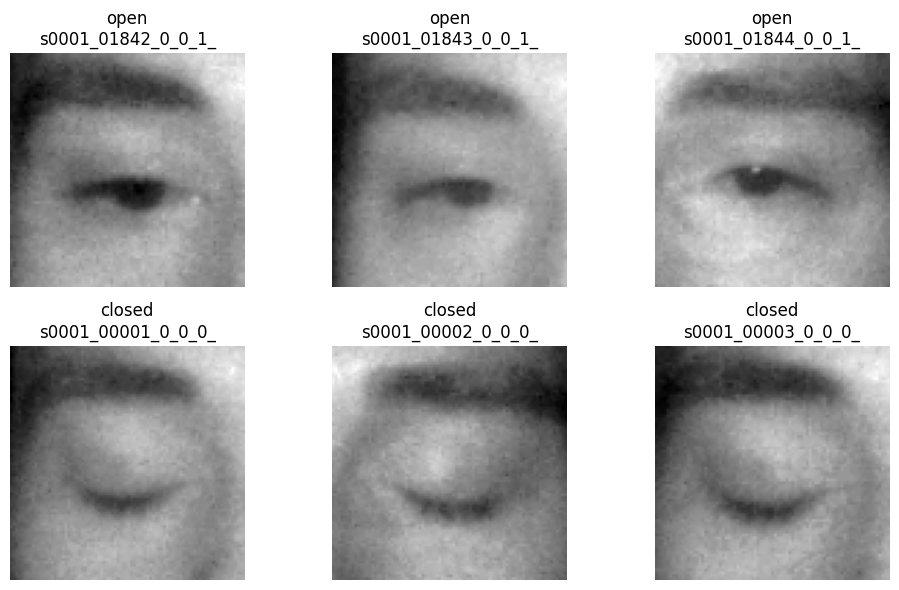

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

open_samples = sorted((RAW_CLEAN_ROOT / "open").glob("*"))[:3]
closed_samples = sorted((RAW_CLEAN_ROOT / "closed").glob("*"))[:3]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, p in enumerate(open_samples):
    img = Image.open(p)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"open\n{p.name[:18]}")
    axes[0, i].axis("off")

for i, p in enumerate(closed_samples):
    img = Image.open(p)
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title(f"closed\n{p.name[:18]}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
print("Phase 0 complete.")
print("Canonical clean dataset root:", RAW_CLEAN_ROOT)


Phase 0 complete.
Canonical clean dataset root: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/raw_clean
